<a href="https://colab.research.google.com/github/Himanshu3557/himanshu3557/blob/main/Himanshu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
pd.read_csv("/content/drive/MyDrive/large_uncleaned_dataset.csv")

,EmployeeID,Name,Age,City,Salary,Department
0,1,John,40,Los Angeles,45000.0,HR
1,2,Sarah,25,NaN,35000.0,Sales
2,3,Bob,NaN,New York,75000.0,HR
3,4,Sarah,unknown,Los Angeles,65000.0,NaN
4,5,John,30,NaN,55000.0,IT
...,...,...,...,...,...,...
5195,1097,NaN,25,Mumbai,55000.0,NaN
5196,830,David,30,Chicago,35000.0,Sales
5197,2806,Chris,22,NaN,75000.0,HR
5198,3830,NaN,22,Los Angeles,NaN,HR


In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("/content/drive/MyDrive/large_uncleaned_dataset.csv")
df.head()

,EmployeeID,Name,Age,City,Salary,Department
0,1,John,40,Los Angeles,45000.0,HR
1,2,Sarah,25,NaN,35000.0,Sales
2,3,Bob,NaN,New York,75000.0,HR
3,4,Sarah,unknown,Los Angeles,65000.0,NaN
4,5,John,30,NaN,55000.0,IT


In [8]:
df.head()

,EmployeeID,Name,Age,City,Salary,Department
0,1,John,40,Los Angeles,45000.0,HR
1,2,Sarah,25,NaN,35000.0,Sales
2,3,Bob,NaN,New York,75000.0,HR
3,4,Sarah,unknown,Los Angeles,65000.0,NaN
4,5,John,30,NaN,55000.0,IT


In [7]:
df.shape

(5200, 6)

In [9]:
df.columns

Index(['EmployeeID', 'Name', 'Age', 'City', 'Salary', 'Department'], dtype='object')

In [10]:
df.dtypes

,0
EmployeeID,int64
Name,object
Age,object
City,object
Salary,float64
Department,object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EmployeeID  5200 non-null   int64  
 1   Name        4000 non-null   object 
 2   Age         4111 non-null   object 
 3   City        3922 non-null   object 
 4   Salary      3738 non-null   float64
 5   Department  3437 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 243.9+ KB


In [12]:
df.isnull().sum()

,0
EmployeeID,0
Name,1200
Age,1089
City,1278
Salary,1462
Department,1763


In [13]:
(df.isnull().sum()/len(df))*100

,0
EmployeeID,0.000000
Name,23.076923
Age,20.942308
City,24.576923
Salary,28.115385
Department,33.903846


In [14]:
df.duplicated().sum()

np.int64(200)

In [15]:
df[df.duplicated()]

,EmployeeID,Name,Age,City,Salary,Department
5000,1502,Mary,25,Chicago,55000.0,Sales
5001,2587,Alice,30,Chicago,75000.0,HR
5002,2654,John,40,Mumbai,65000.0,Sales
5003,1056,David,25,NaN,NaN,Sales
5004,706,David,NaN,Delhi,75000.0,NaN
...,...,...,...,...,...,...
5195,1097,NaN,25,Mumbai,55000.0,NaN
5196,830,David,30,Chicago,35000.0,Sales
5197,2806,Chris,22,NaN,75000.0,HR
5198,3830,NaN,22,Los Angeles,NaN,HR


In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df["EmployeeID"].duplicated().sum()

np.int64(101)

In [19]:
df[df["EmployeeID"].duplicated(keep=False)]

,EmployeeID,Name,Age,City,Salary,Department
4,5,John,30,NaN,55000.0,IT
19,20,NaN,25,NaN,65000.0,NaN
32,725,John,35,Chicago,35000.0,IT
35,36,Mary,unknown,Mumbai,65000.0,Finance
40,41,John,25,Los Angeles,45000.0,Finance
...,...,...,...,...,...,...
4754,140,Chris,30,NaN,NaN,NaN
4907,616,Chris,Thirty,NaN,55000.0,NaN
4920,637,Bob,40,Houston,55000.0,NaN
4942,347,Mary,NaN,NaN,35000.0,NaN


In [20]:
df = df.drop_duplicates(subset="EmployeeID")

In [21]:
df["Name"].unique()

array(['John', '  Sarah  ', 'Bob', 'David', nan, 'Chris', 'Mary', 'Alice'],
      dtype=object)

In [22]:
df["Name"] = df["Name"].str.strip()

In [23]:
df["Name"] = df["Name"].fillna("Unknown")
df["Name"] = df["Name"].replace("", "Unknown")

In [24]:
df["Name"].value_counts()

,count
Name,
Unknown,1135
Mary,591
Alice,549
Sarah,546
John,542
Chris,519
David,515
Bob,502


In [25]:
df["Age"].unique()

array(['40', '25', nan, 'unknown', '30', '35', '22', 'Thirty'],
      dtype=object)

In [26]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

In [27]:
df["Age"].isnull().sum()

np.int64(2137)

In [28]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [29]:
df["Age"] = df["Age"].astype(int)

In [30]:
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")

In [31]:
df["Salary"].isnull().sum()

np.int64(1369)

In [32]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

In [33]:
df["City"].unique()

array(['Los Angeles', nan, 'New York', 'Chicago', 'Delhi', 'Houston',
       'Mumbai'], dtype=object)

In [34]:
df["City"] = df["City"].str.strip()

In [35]:
df["City"] = df["City"].fillna("Unknown")
df["City"] = df["City"].replace("", "Unknown")

In [36]:
df["Department"].unique()

array(['HR', 'Sales', nan, 'IT', 'Finance'], dtype=object)

In [37]:
df["Department"] = df["Department"].fillna("Not Assigned")
df["Department"] = df["Department"].replace("", "Not Assigned")

In [38]:
df["Salary"].describe()

,Salary
count,4899.000000
mean,54975.505205
std,11966.649762
min,35000.000000
25%,45000.000000
50%,55000.000000
75%,65000.000000
max,75000.000000


In [39]:
df["Age"].describe()

,Age
count,4899.000000
mean,30.174321
std,4.937733
min,22.000000
25%,30.000000
50%,30.000000
75%,30.000000
max,40.000000


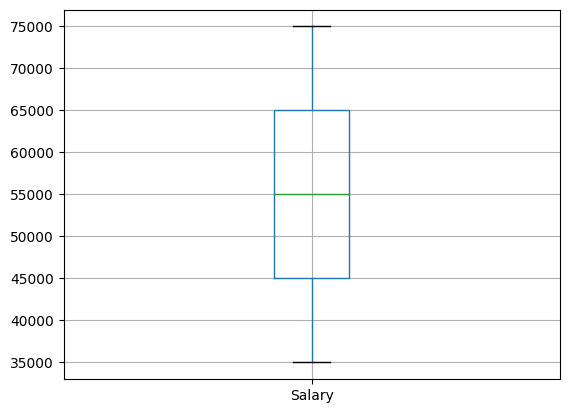

In [40]:
import matplotlib.pyplot as plt

df.boxplot(column="Salary")
plt.show()

In [41]:
df.isnull().sum()

,0
EmployeeID,0
Name,0
Age,0
City,0
Salary,0
Department,0


In [42]:
df.dtypes

,0
EmployeeID,int64
Name,object
Age,int64
City,object
Salary,float64
Department,object


In [43]:
df.to_csv("cleaned_employee_dataset.csv", index=False)

In [45]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/large_uncleaned_dataset.csv")

df = df.drop_duplicates()
df = df.drop_duplicates(subset="EmployeeID")

df["Name"] = df["Name"].str.strip()
df["Name"] = df["Name"].fillna("Unknown")
df["Name"] = df["Name"].replace("", "Unknown")

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Age"] = df["Age"].astype(int)

df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

df["City"] = df["City"].str.strip()
df["City"] = df["City"].fillna("Unknown")
df["City"] = df["City"].replace("", "Unknown")

df["Department"] = df["Department"].fillna("Not Assigned")
df["Department"] = df["Department"].replace("", "Not Assigned")

df.to_csv("cleaned_employee_dataset.csv", index=False)

print("Dataset cleaned successfully!")

Dataset cleaned successfully!


QUESTIONS


1. Department-wise Salary Analysis

Find the average, median, minimum, and maximum salary for each department.

In [46]:
df.groupby("Department")["Salary"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Department,,,,
Finance,55206.812652,55000.0,35000.0,75000.0
HR,54357.060850,55000.0,35000.0,75000.0
IT,54863.692689,55000.0,35000.0,75000.0
Not Assigned,55205.190103,55000.0,35000.0,75000.0
Sales,55053.908356,55000.0,35000.0,75000.0


2. Top Paying Department

Which department has the highest average salary?

In [47]:
df.groupby("Department")["Salary"].mean().idxmax()

'Finance'

3. Salary Outlier Detection

Identify employees whose salary is above the 95th percentile.

In [48]:
threshold = df["Salary"].quantile(0.95)
df[df["Salary"] > threshold]

,EmployeeID,Name,Age,City,Salary,Department


4. Age Group Analysis

Create age groups and calculate average salary for each.

In [49]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[20,30,40,50],
    labels=["20-30","30-40","40-50"]
)

df.groupby("Age_Group")["Salary"].mean()

/tmp/ipykernel_4011/2593971877.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age_Group")["Salary"].mean()


,Salary
Age_Group,
20-30,54902.887139
30-40,55229.568411
40-50,NaN


5. Department Salary Share

What percentage of the company's total salary expense belongs to each department?

In [50]:
salary_share = (
    df.groupby("Department")["Salary"].sum()
    / df["Salary"].sum()
)*100

6. Correlation Between Age and Salary

In [51]:
df[["Age","Salary"]].corr()

,Age,Salary
Age,1.00000,-0.00321
Salary,-0.00321,1.00000


7. Top 3 Earners Per Department

In [52]:
df.sort_values(
    ["Department","Salary"],
    ascending=[True,False]
).groupby("Department").head(3)

,EmployeeID,Name,Age,City,Salary,Department,Age_Group
70,71,Chris,22,Chicago,75000.0,Finance,20-30
110,111,Mary,22,Mumbai,75000.0,Finance,20-30
132,133,Mary,35,Chicago,75000.0,Finance,30-40
2,3,Bob,30,New York,75000.0,HR,20-30
22,23,Unknown,22,Delhi,75000.0,HR,20-30
31,32,John,30,Los Angeles,75000.0,HR,20-30
24,25,Sarah,30,New York,75000.0,IT,20-30
51,52,Mary,25,Los Angeles,75000.0,IT,20-30
74,75,David,25,Delhi,75000.0,IT,20-30
11,12,Chris,25,Houston,75000.0,Not Assigned,20-30


8. Employee Distribution Heatmap Data

In [53]:
pd.crosstab(
    df["City"],
    df["Department"]
)

Department,Finance,HR,IT,Not Assigned,Sales
City,,,,,
Chicago,103,129,103,231,82
Delhi,84,106,85,204,91
Houston,102,123,124,222,96
Los Angeles,102,105,120,185,99
Mumbai,116,102,101,210,79
New York,114,97,84,208,95
Unknown,201,209,190,397,200


9. Find Departments with Above-average Salary

In [54]:
dept_avg = df.groupby("Department")["Salary"].mean()

dept_avg[dept_avg > df["Salary"].mean()]

,Salary
Department,
Finance,55206.812652
Not Assigned,55205.190103
Sales,55053.908356


10. City-Department Combination with Highest Salary

In [55]:
df.groupby(
    ["City","Department"]
)["Salary"].mean().sort_values(
    ascending=False
).head(1)

,,Salary
City,Department,
New York,Sales,57736.842105
